# Explore here

Top 10 Drake Tracks on Last.fm:
                      track_name  playcount  listeners  duration_ms  duration_min
0                      One Dance   21402256    1873035       173000      2.883333
1                Best I Ever Had   12071029    1770732       261000      4.350000
2                   Passionfruit   26729203    1541935       298000      4.966667
3                     God's Plan   14155463    1412450       198000      3.300000
4                  Hotline Bling   11960059    1377679       267000      4.450000
5                        Forever    6507931    1233917       357000      5.950000
6      Hold On, We're Going Home   14364425    1212518       227000      3.783333
7                      Headlines   14586116    1092529       235000      3.916667
8  Jimmy Cooks (feat. 21 Savage)   17071575    1010151       218000      3.633333
9                           Over    6471160     987306       159000      2.650000


Bottom 3 tracks by listeners:
                      track_name  

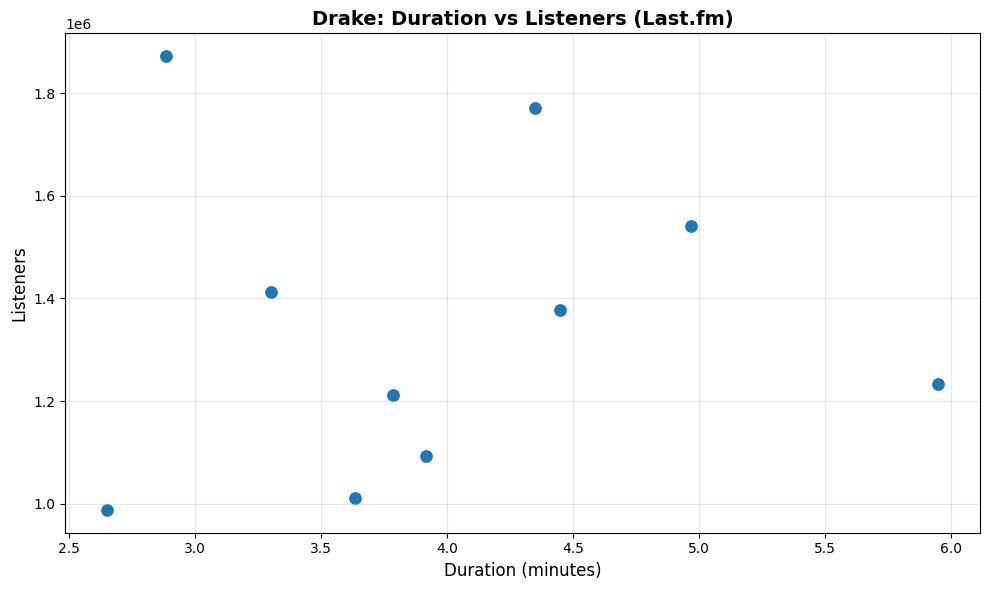

Tracks with their top tags:
  One Dance: Drake, Kyla, wizkid, pop, 2016
  Best I Ever Had: Drake, Hip-Hop, rap, Best I Ever Had, hip hop
  Passionfruit: rnb, tropical house, House, 2017, dance
  God's Plan: 2018, rap, Hip-Hop, 2010s, Drake
  Hotline Bling: Hip-Hop, pop, 2015, rnb, i want drake to murder my vagina
  Forever: Hip-Hop, Drake, rap, Eminem, forever
  Hold On, We're Going Home: pop, rnb, 2013, Love, Ballad
  Headlines: rap, Hip-Hop, 2011, hip hop, Canadian
  Jimmy Cooks (feat. 21 Savage): pop rap, trap, Drake, 2022, 21 savage
  Over: Drake, Hip-Hop, rap, hip hop, young money


Top 15 most common track tags:
top_tags
Drake              6
Hip-Hop            6
rap                5
pop                3
hip hop            3
rnb                3
Kyla               1
wizkid             1
2016               1
Best I Ever Had    1
tropical house     1
House              1
2017               1
dance              1
2018               1
Name: count, dtype: int64




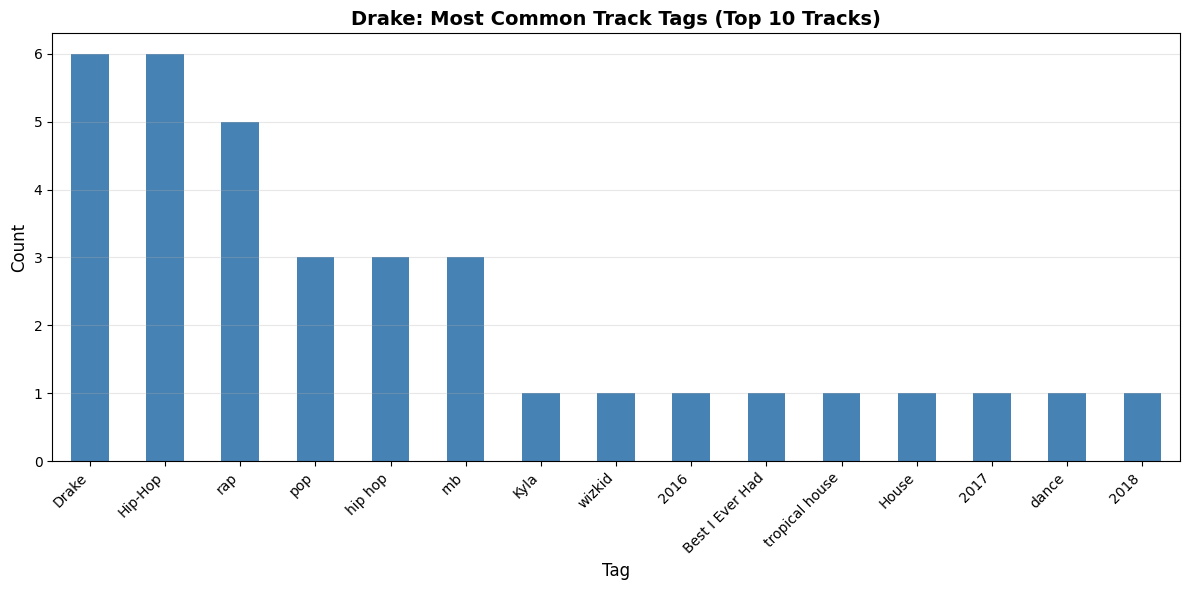

In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

api_key = os.environ.get("LASTFM_API_KEY")
api_secret = os.environ.get("LASTFM_SHARED_SECRET")

import pylast

network = pylast.LastFMNetwork(
    api_key=api_key,
    api_secret=api_secret
)

artist_name = "Drake"
artist = network.get_artist(artist_name)

top_tracks = artist.get_top_tracks(limit=10)

rows = []

for track_obj, weight_obj in top_tracks:
    track_name = track_obj.get_title()

    # popularity proxies
    playcount = track_obj.get_playcount()
    listeners = track_obj.get_listener_count()

    # duration in milliseconds (may be None or 0)
    duration_ms = track_obj.get_duration() or 0

    rows.append({
        "track_name": track_name,
        "playcount": int(playcount) if playcount is not None else 0,
        "listeners": int(listeners) if listeners is not None else 0,
        "duration_ms": int(duration_ms),
        "duration_min": (int(duration_ms) / 60000) if duration_ms else None
    })

df = pd.DataFrame(rows)
print("Top 10 Drake Tracks on Last.fm:")
print(df.to_string())
print("\n")

df_sorted = df.sort_values("listeners", ascending=True)
print("Bottom 3 tracks by listeners:")
print(df_sorted.head(3))
print("\n")

df_clean = df.dropna(subset=["duration_min"]).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="duration_min", y="listeners", s=100)
plt.title(f"{artist_name}: Duration vs Listeners (Last.fm)", fontsize=14, fontweight="bold")
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Listeners", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

def get_top_tags(track_obj, max_tags=5):
    tags = track_obj.get_top_tags(limit=max_tags)
    # tags are (TagObject, WeightObject)
    return [tag.item.get_name() for tag in tags]

df["top_tags"] = [
    get_top_tags(network.get_track(artist_name, name), max_tags=5)
    for name in df["track_name"]
]

df["n_tags"] = df["top_tags"].apply(len)

print("Tracks with their top tags:")
for idx, row in df.iterrows():
    print(f"  {row['track_name']}: {', '.join(row['top_tags'])}")
print("\n")

tags_exploded = df[["track_name", "listeners", "top_tags"]].explode("top_tags")
tag_counts = tags_exploded["top_tags"].value_counts()
print("Top 15 most common track tags:")
print(tag_counts.head(15))
print("\n")

plt.figure(figsize=(12, 6))
tag_counts.head(15).plot(kind="bar", color="steelblue")
plt.title(f"{artist_name}: Most Common Track Tags (Top 10 Tracks)", fontsize=14, fontweight="bold")
plt.xlabel("Tag", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
